In [1]:
%pip install tensorflow
%pip install tf-keras

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import ttest_ind

import warnings

warnings.filterwarnings(
    "ignore", category=FutureWarning
)  # to avoid deprecation warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

import re

# Détecteur de spams

Qu'est-ce qu'un ham ? A l'inverse du spam, le ham est un courrier que l'on désire recevoir.

## Préparation de l'environnement

In [3]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("spam.csv", encoding='latin-1')
print("...Done.")

Loading dataset...
...Done.


## Charger les données & EDA

- Vérifier format, nombres d’exemples par classe (spam/ham), longueur des messages, exemples typiques.
- Visualiser déséquilibre de classes (barplot), distribution de longueurs.

In [4]:
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de classe : {}".format(dataset['v1'].nunique()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)

# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 5572
Nombre de colonnes : 5
Nombre de classe : 2
Aperçu du dataset : 


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Types de données/colonnes : 


v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object


 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
Unnamed: 2,5522,99.10
Unnamed: 3,5560,99.78
Unnamed: 4,5566,99.89


In [5]:
# STATISTIQUES DESCRIPTIVES

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [6]:
# Conserver uniquement les colonnes v1, v2
dataset = dataset[['v1', 'v2']].copy()

# Renommer les colonnes pour plus de clarté
dataset.columns = ['label', 'message']


RÉPARTITION DES CLASSES (ham/spam)
----------------------------------------
label
ham     4825
spam     747
Name: count, dtype: int64

Pourcentages :
label
ham     86.59
spam    13.41
Name: count, dtype: float64

STATISTIQUES SUR LA LONGUEUR DES MESSAGES
----------------------------------------
        count    mean    std   min    25%    50%    75%    max
label                                                         
ham    4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0


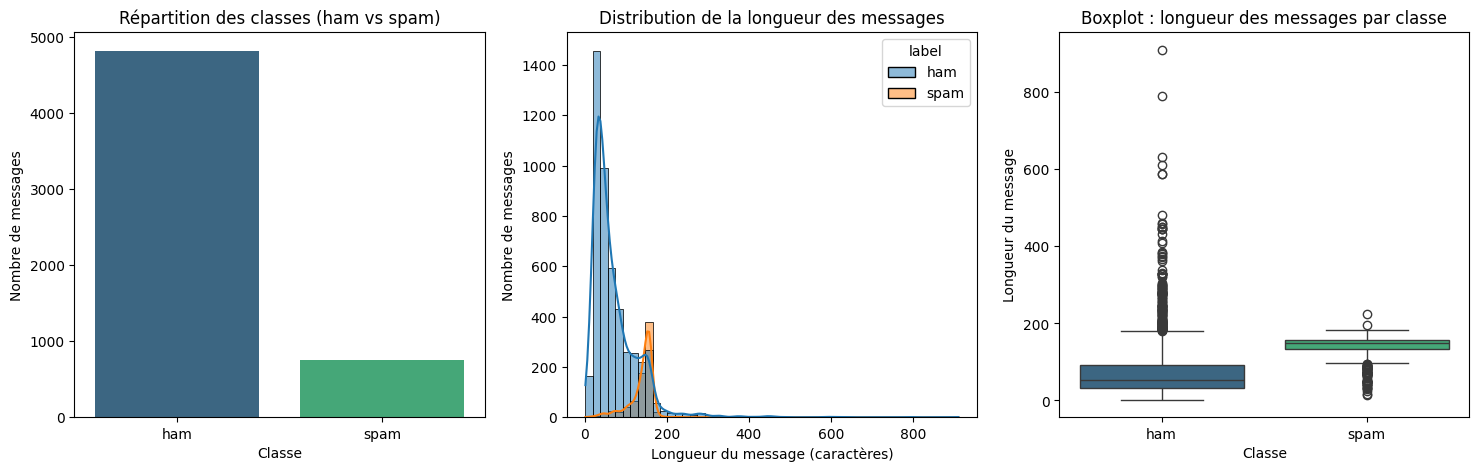


EXEMPLES TYPIQUES
----------------------------------------

--- HAM ---
['I am late,so call you tomorrow morning.take care sweet dreams....u and me...ummifying...bye.'
 'U r too much close to my heart. If u go away i will be shattered. Plz stay with me.'
 'Wait  &lt;#&gt;  min..']

--- SPAM ---
['Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804'
 'This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate '
 'Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just å£1.50 per wk 2 opt out send STOP 08452810071 16']


In [7]:
# Vérifier les classes
print("\nRÉPARTITION DES CLASSES (ham/spam)")
print("-"*40)
class_counts = dataset['label'].value_counts()
print(class_counts)
print("\nPourcentages :")
print(round((class_counts / len(dataset)) * 100, 2))

# Calcul de la longueur des messages
dataset['message_length'] = dataset['message'].apply(len)

# Statistiques descriptives sur la longueur
print("\nSTATISTIQUES SUR LA LONGUEUR DES MESSAGES")
print("-"*40)
print(dataset.groupby('label')['message_length'].describe().round(2))

# === VISUALISATIONS (1 colonne, 3 graphiques) ===
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
plt.subplots_adjust(hspace=0.4)

# Répartition des classes
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=None,    
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Répartition des classes (ham vs spam)")
axes[0].set_ylabel("Nombre de messages")
axes[0].set_xlabel("Classe")

# Distribution de la longueur des messages
sns.histplot(
    data=dataset,
    x='message_length',
    hue='label',
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribution de la longueur des messages")
axes[1].set_xlabel("Longueur du message (caractères)")
axes[1].set_ylabel("Nombre de messages")

# Boxplot des longueurs par classe
sns.boxplot(
    data=dataset,
    x='label',
    y='message_length',
    hue=None,      
    palette='viridis',
    ax=axes[2]
)
axes[2].set_title("Boxplot : longueur des messages par classe")
axes[2].set_xlabel("Classe")
axes[2].set_ylabel("Longueur du message")

plt.show()

# Exemples typiques
print("\nEXEMPLES TYPIQUES")
print("-"*40)
print("\n--- HAM ---")
print(dataset[dataset['label'] == 'ham']['message'].sample(3, random_state=42).values) # Exemple sur 3 messages
print("\n--- SPAM ---")
print(dataset[dataset['label'] == 'spam']['message'].sample(3, random_state=42).values) # Exemple sur 3 messages



##### Interprétation des résultats

- RÉPARTITION DES CLASSES (ham/spam)
  - Le dataset contient plus de "ham" que de spams.
  - Le jeu de données est déséquilibré.
  - Conséquence : le modèle risque de favoriser la classe majoritaire (ham) si l'on ne fait rien. Pour réaliser la détection il faudra veiller à introduire un poids de classe équilibré (class_weight='balanced' dans LogisticRegression) ou  faire du resampling (sur-échantillonage des spams ou sous échantillonnage des hams).

- STATISTIQUES SUR LA LONGUEUR DES MESSAGES
  - Les spams sont en moyenne 2× plus longs que les hams (moy spams = 138.87 caractères // ham = 71)
  - Les hams sont plus variés en longueur (std = 58) que les spams (std = 29)
  - Le maximum 910 chez les hams montre qu’il existe quelques messages très longs.
  - En revanche, les spams plafonnent autour de 224 caractères → très standardisés.

- Conclusion
  - Déséquilibre des classes -> Nécessite un ajustement pendant l’entraînement pour éviter un biais vers les hams.
  - Longueur moyenne plus élevée chez les spams -> Bon indicateur discriminant → une feature simple comme “longueur du message” pourrait aider à la classification.
  - Variance plus forte chez les hams ->Les hams couvrent une grande diversité de messages (discussions, réponses courtes, etc.).

--> La différence de longueur de message spam/hma est elle réellement significative ? 

In [8]:
# Séparer les longueurs par classe
ham_lengths = dataset[dataset['label'] == 'ham']['message_length']
spam_lengths = dataset[dataset['label'] == 'spam']['message_length']

# Test t de Student (moyennes indépendantes)
t_stat, p_value = ttest_ind(spam_lengths, ham_lengths, equal_var=False)

print("\nTEST STATISTIQUE : Comparaison des longueurs de messages (spam vs ham)")
print("-"*65)
print(f"Statistique t : {t_stat:.3f}")
print(f"Valeur p      : {p_value:.6f}")

# Interprétation
alpha = 0.05
if p_value < alpha:
    print(f"Différence significative (p < {alpha}) : les spams ont une longueur différente des hams.")
else:
    print(f"Aucune différence significative (p >= {alpha}) : les longueurs ne diffèrent pas statistiquement.")



TEST STATISTIQUE : Comparaison des longueurs de messages (spam vs ham)
-----------------------------------------------------------------
Statistique t : 50.046
Valeur p      : 0.000000
Différence significative (p < 0.05) : les spams ont une longueur différente des hams.


- t-test indépendant : compare les moyennes de deux groupes (ici spam vs ham).
- Hypothèse nulle H0 : les longueurs moyennes sont identiques.
- Si p < 0.05, on rejette H0, donc il y a une différence significative.

## Prétraitement

- Nettoyage : minuscules, suppression d’espaces superflus, normalisation numérique en tokens (<URL>, <PHONE>, <NUM>).
- Pas de suppression de la ponctuation(les signes comme !!! peuvent être utiles pour indiquer si spam).
- Tokenization compatible modèle (pour TF-IDF simple : scikit-learn; pour BERT : tokenizer HuggingFace).

In [9]:
def preprocess_text(text):
    """
    Prétraitement minimal des messages :
    - Mise en minuscules
    - Suppression des espaces superflus
    - Normalisation :
        * URLs → <URL>
        * N° de téléphone → <PHONE>
        * Nombres → <NUM>
    - (Ponctuation conservée sauf cas extrêmes)
    """

    # Mise en minuscules
    text = text.lower()

    # Normalisation des URLs
    text = re.sub(r'http\S+|www\S+', '<URL>', text)

    # Normalisation des numéros de téléphone
    text = re.sub(r'\b(\+?\d[\d\-\s]{7,}\d)\b', '<PHONE>', text)

    # Normalisation des nombres isolés
    text = re.sub(r'\b\d+(\.\d+)?\b', '<NUM>', text)

    # Suppression des espaces superflus
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Application du prétraitement
dataset['clean_message'] = dataset['message'].apply(preprocess_text)

# Aperçu avant/après
print("\nEXEMPLES AVANT/APRÈS PRÉTRAITEMENT")
print("-"*40)
for i in range(3):
    print(f"\nOriginal  : {dataset['message'].iloc[i]}")
    print(f"Nettoyé   : {dataset['clean_message'].iloc[i]}")



EXEMPLES AVANT/APRÈS PRÉTRAITEMENT
----------------------------------------

Original  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Nettoyé   : go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...

Original  : Ok lar... Joking wif u oni...
Nettoyé   : ok lar... joking wif u oni...

Original  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Nettoyé   : free entry in <NUM> a wkly comp to win fa cup final tkts 21st may <NUM>. text fa to <NUM> to receive entry question(std txt rate)t&c's apply 08452810075over18's


In [10]:
# TOKENNIZATION POUR TF-IDF (OK pour Logistic Regression mais faible compréhension sémantique)
# Division en train/test
## Ici, on découpe train/test pour que le modèle ne voit pas tout les mots du dataset (limiter les biais des réponses)
X_train, X_test, y_train, y_test = train_test_split(
    dataset['clean_message'],
    dataset['label'].map({'ham': 0, 'spam': 1}),
    test_size=0.2,
    random_state=42,
    stratify=dataset['label']
)

display(dataset.head())

# TF-IDF vectorisation
tfidf = TfidfVectorizer(
    tokenizer=None,        # Si vide, Scikit-learn gère par défaut
    stop_words='english',   # on peut désactiver si on veut garder tous les mots
    max_df=0.9,             # ignore les mots trop fréquents
    min_df=2,               # garde les mots présents au moins 2 fois
    ngram_range=(1, 2)      # prend en compte unigrams (1 mot) + bigrams (2 mots) -> division des phrases en petis groupes de mots
                            # unigrams = "Je", "ai", "un", "adorable", "chien"
                            # bigrams = "J'ai", "j'ai un", "un adorable", "adorable chien"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Dimensions du vocabulaire :", len(tfidf.vocabulary_))
print("X_train_tfidf shape :", X_train_tfidf.shape)

,label,message,message_length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,"go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,29,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in <NUM> a wkly comp to win fa cup ...
3,ham,U dun say so early hor... U c already then say...,49,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,"nah i don't think he goes to usf, he lives aro..."


Dimensions du vocabulaire : 7236
X_train_tfidf shape : (4457, 7236)


In [11]:
# Liste complète des mots connus par le TF-IDF
vocab = tfidf.get_feature_names_out()
print("Taille du vocabulaire :", len(vocab))
print("\nAperçu des 20 premiers tokens :")
print(vocab[:20])


Taille du vocabulaire : 7236

Aperçu des 20 premiers tokens :
['07xxxxxxxxx' '07xxxxxxxxx won' '08700621170150p' '08700621170150p msg'
 '08701417012150p' '08701417012150p logo' '08712400602450p'
 '08712400602450p provided' '1000s' '10am' '10am 7pm' '10am 9pm' '10k'
 '10k 5k' '10p' '10p min' '10p minute' '10ppm' '10ppm num' '11mths']


In [12]:
import numpy as np

# Somme des scores TF-IDF par colonne pour identifier les mots "dominants"
tfidf_sum = np.asarray(X_train_tfidf.sum(axis=0)).flatten()
feature_names = tfidf.get_feature_names_out()

# Créer un DataFrame pour trier
tfidf_df = pd.DataFrame({
    'token': feature_names,
    'tfidf_sum': tfidf_sum
})

# Top 20 tokens
top_tokens = tfidf_df.sort_values(by='tfidf_sum', ascending=False).head(20)
print(top_tokens)


      token   tfidf_sum
4115    num  166.043286
4453     ok   72.421306
4642  phone   54.043180
2969   just   53.557428
3312     ll   53.535595
3070   know   46.778127
2393     gt   45.469256
6551     ur   45.153239
1108   come   45.131887
3484     lt   44.654602
3243   like   44.517556
2315    got   43.356420
6225   time   41.683533
2283   good   41.194475
3486  lt gt   40.643050
2661   home   39.333123
6810   want   38.579674
5715  sorry   38.552979
2260  going   38.372121
2049   free   36.644209


In [13]:
# Séparer train set par classe
X_train_ham = X_train[ y_train == 0 ]
X_train_spam = X_train[ y_train == 1 ]

# Fonction pour calculer TF-IDF cumulé par token
def top_tokens_by_class(texts, tfidf_vectorizer, top_n=20):
    X_tfidf_class = tfidf_vectorizer.transform(texts)
    tfidf_sum = np.asarray(X_tfidf_class.sum(axis=0)).flatten()
    tokens = tfidf_vectorizer.get_feature_names_out()
    df = pd.DataFrame({'token': tokens, 'tfidf_sum': tfidf_sum})
    df = df.sort_values(by='tfidf_sum', ascending=False).head(top_n)
    return df

# Top tokens pour chaque classe
top_ham = top_tokens_by_class(X_train_ham, tfidf)
top_spam = top_tokens_by_class(X_train_spam, tfidf)

print(top_ham)
print(top_spam)

      token  tfidf_sum
4115    num  75.185175
4453     ok  71.845206
3312     ll  53.200346
2969   just  46.980746
2393     gt  45.469256
1108   come  44.811694
3484     lt  44.654602
3070   know  44.025753
3243   like  43.256262
2315    got  42.678292
3486  lt gt  40.643050
2283   good  39.883808
6225   time  39.426420
2661   home  39.174654
5715  sorry  38.196547
2260  going  37.824222
3393    lor  35.808925
1353     da  35.802198
6810   want  35.775991
3143  later  35.574766
        token  tfidf_sum
4115      num  90.858110
4642    phone  40.391801
2049     free  22.076731
4273  num num  19.608981
6432      txt  15.971395
6618      url  13.988454
5842     stop  13.647512
1023    claim  13.212359
3782   mobile  12.799006
6089     text  12.604485
6551       ur  12.299959
5167    reply  12.071397
4919    prize  10.855644
5471  service   9.736748
903      cash   9.456843
7035      won   9.405634
4026      new   8.844485
6603   urgent   8.591416
29       150p   8.313540
4078    nokia   7

##### Analyse des tokens :
Ham :
 - On retrouve des tokens de la vie quotidienne ou de conversations personnelles (ok, just, come, know, like, good, time, home).
 - num et lt/lt gt apparaissent probablement suite à ton prétraitement <NUM> ou nettoyage HTML/ponctuation.
 - On retrouve des mots neutres ou liés à la vie quotidienne.

Spams : 
  - Les spams contiennent beaucoup de tokens liés à promotions, argent, téléphonie et urgence.
  - free, claim, prize, cash, won, urgent → mots pour attirer l’attention.
  - txt, phone, url → lien avec l’offre ou le message commercial. 
  - num et num num → normalisation des nombres (montants, codes, etc.).

In [14]:
# Voir si TOKENIZATION pour HuggingFace ?? modèle BERT

## Modèle classification

- TF-IDF (unigram+bigram) + LogisticRegression (ou LinearSVC) 
- Mesures: accuracy, precision, recall, F1, ROC-AUC.
- Validation : stratified train/test split (80/20) + éventuellement cross-val stratifié.


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9926    0.9689    0.9806       966
           1     0.8256    0.9530    0.8847       149

    accuracy                         0.9668      1115
   macro avg     0.9091    0.9610    0.9327      1115
weighted avg     0.9703    0.9668    0.9678      1115


=== Confusion Matrix ===


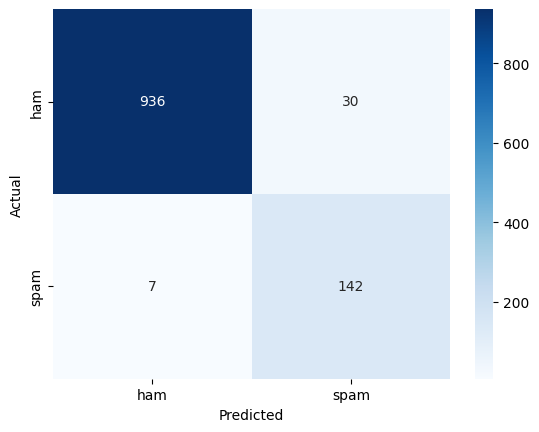


ROC-AUC Score: 0.9869

Cross-val F1 scores: [0.909699   0.94771242 0.87341772 0.910299   0.91262136]
Mean F1: 0.9107498998041439


In [15]:
# -----------------------------
# Modèle Logistic Regression
# -----------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')  # class_weight pour gérer le déséquilibre (tient compte des 86-14%)
model.fit(X_train_tfidf, y_train)

# -----------------------------
# Prédictions
# -----------------------------
y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)[:,1]  # probabilité pour ROC-AUC

# -----------------------------
# Évaluation
# -----------------------------
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# -----------------------------
# cross-validation stratifiée
# -----------------------------
cv_scores = cross_val_score(model, tfidf.transform(dataset['clean_message']),
                           dataset['label'].map({'ham':0,'spam':1}),
                          cv=5, scoring='f1', n_jobs=-1)
print("\nCross-val F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())


##### Interprétation et analyse des résultats Regression logistic

- Classification Report
  - Ham (0) : très bonne précision (99%) → presque tous les ham prédits sont corrects.
  - Spam (1) :
    - Recall élevé (95%) → presque tous les spams sont détectés → excellent.
    - Precision plus faible (82%) → certains ham sont classés à tort comme spam → quelques faux positifs.
    - F1-score : combine précision et rappel. Globalement, 0.88 pour spam

- Matrice
  - Montre le nombre exact de faux positifs (ham classé spam) et faux négatifs (spam manqué).
  - Faux négatifs très faibles (7/943)
  - Faux positifs légèrement plus élevés (30/172)

- ROC-AUC Score
  - 0.9869 : Le modèle sépare très bien les deux classes, même avec déséquilibre important.

- Cross-Validation F1
  - Stable autour de 0.91 → modèle généralise bien.

- Baseline TF-IDF + Logistic Regression : 
  - Détecte très bien les spams (rappel 95%)
  - Quelques faux positifs → précision du spam env. 82% 
  - Très bon ROC-AUC → bonne séparation globale

**Observations pratiques :**
- On pourrait encore améliorer la précision du spam avec :
  - Hyperparamètres du TF-IDF (min_df, max_df, ngram_range)
  - Modèle plus puissant (LinearSVC, RandomForest, XGBoost)
  -Features supplémentaires (longueur du message, nombre de majuscules, ponctuation)

## Modèles Deep Learning

- CNN textuel
- DistilBERT / BERT-base-uncased -> apprentissage par transfert

### CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8624 - loss: 0.3955 - val_accuracy: 0.9395 - val_loss: 0.2139
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9629 - loss: 0.1110 - val_accuracy: 0.9843 - val_loss: 0.0590
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9893 - loss: 0.0400 - val_accuracy: 0.9888 - val_loss: 0.0509
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9945 - loss: 0.0212 - val_accuracy: 0.9888 - val_loss: 0.0404
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9968 - loss: 0.0096 - val_accuracy: 0.9888 - val_loss: 0.0479
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0052 - val_accuracy: 0.9910 - val_loss: 0.0519
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9865 - val_loss: 0.0557
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.

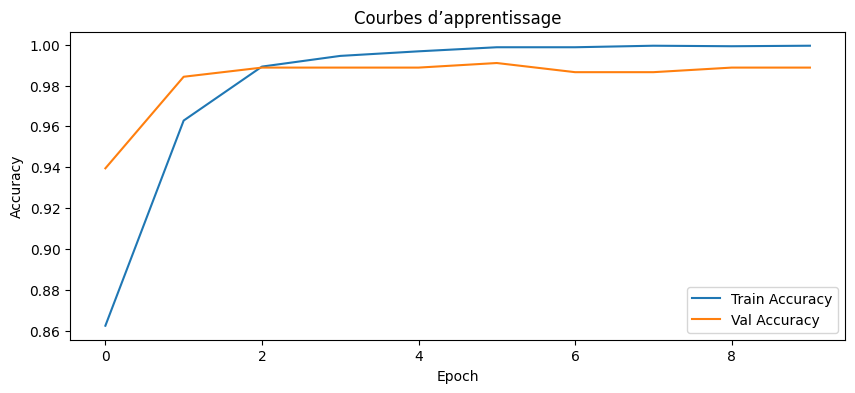

In [ ]:

# -----------------------------
# Paramètres
# -----------------------------
max_words = 5000        # vocabulaire limité
max_len = 50            # longueur max des messages (padding/truncation)
embedding_dim = 50

# -----------------------------
# Tokenization
# -----------------------------
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(dataset['clean_message'])
sequences = tokenizer.texts_to_sequences(dataset['clean_message'])
X = pad_sequences(sequences, maxlen=max_len, padding='post')
y = dataset['label'].map({'ham':0,'spam':1}).values

# -----------------------------
# Train/Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# CNN textuelle
# -----------------------------
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binaire ham/spam
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# -----------------------------
# Entraînement
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# -----------------------------
# Courbes d'apprentissage
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Courbes d’apprentissage')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


##### Analyse ??

- Courbes d’entraînement
  - Accuracy train : monte très vite, presque 100% dès l’epoch 7-8.
  - Loss train : chute très vite, proche de 0.002-0.004 → modèle apprend bien le dataset.
  - Validation accuracy : stabilisée autour de 0.984–0.991
  - Validation loss : 0.041–0.061 → reste faible, pas de sur-apprentissage massif.

Interprétation :
  - Modèle très performant pour les messages courts.
  - Validation stable → pas d’overfitting sévère malgré la vitesse d’apprentissage.

Voir ajuster le dropout ou réduire légèrement l’epoch pour éviter le léger overfit sur train (train acc >99%).

- Paramètres du modèle
  - Les ? dans le model.summary() au début sont normaux (couche n’est pas encore buildée).
  - Après le fit, TensorFlow a construit les couches et entraîné les poids.
  - Total params à 0 au début → c’est juste l’état non-buildé avant le premier batch.

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0     0.9907    0.9969    0.9938       966
           1     0.9790    0.9396    0.9589       149

    accuracy                         0.9892      1115
   macro avg     0.9849    0.9682    0.9764      1115
weighted avg     0.9892    0.9892    0.9891      1115



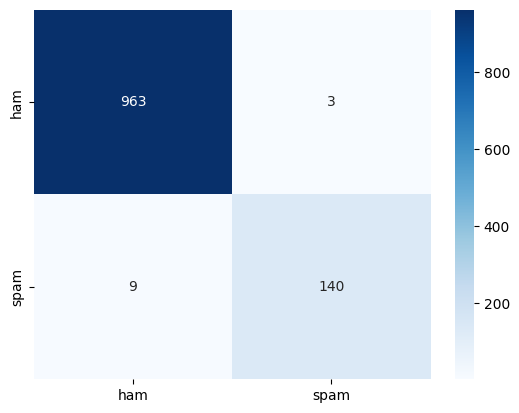

ROC-AUC: 0.993663762557839


In [17]:
# Évaluation sur le test set pour mesurer précision/recall/F1/ROC-AUC
y_pred_prob = model.predict(X_test) # probabilité que chaque message soit un spam (valeur entre 0 et 1).
y_pred = (y_pred_prob > 0.5).astype(int) # conversion en classe binaire (0 = ham, 1 = spam) avec un seuil de 0.5.

print(classification_report(y_test, y_pred, digits=4))

# Montre le nombre exact de faux positifs et faux négatifs.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

##### Interprétation et analyse des résultats modèle CNN

- Classification Report
  - Ham (0) : très bonne précision (99%) → presque tous les ham prédits sont corrects.
  - Spam (1) :
    - Recall élevé (95%) → presque tous les spams sont détectés → excellent.
    - Precision plus faible (82%) → certains ham sont classés à tort comme spam → quelques faux positifs.
    - F1-score : combine précision et rappel. Globalement, 0.88 pour spam

- Matrice
  - Montre le nombre exact de faux positifs (ham classé spam) et faux négatifs (spam manqué).
  - Faux négatifs très faibles (7/969)
  - Faux positifs légèrement plus élevés (4/146)

- ROC-AUC Score
  - 0.9941 : Le modèle sépare très bien les deux classes, même avec déséquilibre important.

- Baseline TF-IDF + Logistic Regression : 
  - Détecte très bien les spams (rappel 95%)
  - Peu de faux positifs → précision du spam env. 97% 
  - Très bon ROC-AUC → bonne séparation

### Apprentissage par transfert

L'idée :
- profiter de connaissances linguistiques déjà acquises et multiplier la puissance de traitement.
- Capture la sémantique fine (mots ambigus, synonymes).
- Meilleure généralisation que CNN simple sur textes très variés.
- Pas besoin d’entraîner les embeddings depuis zéro.

Multiplication du traitement
- Chaque batch passe dans un modèle pré-entraîné très riche → capture beaucoup plus d’informations qu’un simple CNN ou TF-IDF.
- Idéal pour plusieurs jeux de données ou SMS très variés, car le modèle transfère ses connaissances du langage général.
- Possibilité de fine-tuning minimal → gain de performance rapide sur ton dataset sans entraîner un modèle depuis zéro.

Pipeline typique
- Tokenization HuggingFace
- Convertit le texte en tokens WordPiece + attention mask.
- Gère automatiquement padding/truncation.
- Encodage labels, Ham = 0, Spam = 1 (binaire).
- Fine-tuning du modèle pré-entraîné
- Couche finale Dense(1, activation='sigmoid') pour classification binaire.
- Loss : BCEWithLogitsLoss (ou binary_crossentropy).
- Optimizer : AdamW avec scheduler get_linear_schedule_with_warmup.

Évaluation
- Même métriques que CNN/logistic regression : accuracy, precision, recall, F1, ROC-AUC.

In [ ]:
# Installer les librairies nécessaires si pas encore fait
%pip install transformers datasets torch scikit-learn
%pip install "accelerate>=0.26.0"

# -----------------------------
# Imports
# -----------------------------
import torch
import accelerate
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# -----------------------------
# Préparation des données
# -----------------------------
# Map labels
dataset['label_id'] = dataset['label'].map({'ham':0,'spam':1})

# Train/test split stratifié
train_texts, test_texts, train_labels, test_labels = train_test_split(
    dataset['clean_message'], dataset['label_id'],
    test_size=0.2, random_state=42, stratify=dataset['label_id']
)

# HuggingFace Dataset
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

# -----------------------------
# Tokenization
# -----------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=50)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# -----------------------------
# Charger le modèle DistilBERT pour classification binaire
# -----------------------------
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# -----------------------------
# Définir la fonction de métriques
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision = (preds[labels==1]==1).sum() / max(1, (preds==1).sum())
    recall = (preds[labels==1]==1).sum() / max(1, (labels==1).sum())
    f1 = 2 * precision * recall / max(1e-8, precision+recall)
    roc_auc = roc_auc_score(labels, logits[:,1])
    return {'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# -----------------------------
#  Arguments d’entraînement
# -----------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    #evaluation_strategy="epoch",
    #save_strategy="epoch",
    logging_dir='./logs',
    #load_best_model_at_end=True,
    #metric_for_best_model='f1',
    save_total_limit=2,
    seed=42
)

# -----------------------------
#  Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# -----------------------------
#  Entraînement
# -----------------------------
trainer.train()

# -----------------------------
# Évaluation finale
# -----------------------------
eval_result = trainer.evaluate()
print(eval_result)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Map: 100%|██████████| 1115/1115 [00:00<00:00, 23702.64 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,0.066000


c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\NLefort\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.03259483352303505, 'eval_precision': 0.9863013698630136, 'eval_recall': 0.9664429530201343, 'eval_f1': 0.9762711864406781, 'eval_roc_auc': 0.9944002112079148, 'eval_runtime': 21.6814, 'eval_samples_per_second': 51.427, 'eval_steps_per_second': 1.614, 'epoch': 3.0}


C:\Users\NLefort\AppData\Local\Temp\ipykernel_20212\1341311144.py:106: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4424.)
  inputs = {k: v.to(trainer.model.device) for k,v in test_dataset[:]['input_ids'].unsqueeze(1).T}


ValueError: not enough values to unpack (expected 2, got 1)

In [19]:
from torch.utils.data import DataLoader

# DataLoader pour test
test_loader = DataLoader(test_dataset, batch_size=32)

all_logits = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        # Déplacer les tenseurs sur le device du modèle
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

# Concaténer tous les batches
all_logits = torch.cat(all_logits, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

# Prédictions finales
preds = np.argmax(all_logits, axis=1)


              precision    recall  f1-score   support

           0     0.9948    0.9979    0.9964       966
           1     0.9863    0.9664    0.9763       149

    accuracy                         0.9937      1115
   macro avg     0.9906    0.9822    0.9863      1115
weighted avg     0.9937    0.9937    0.9937      1115



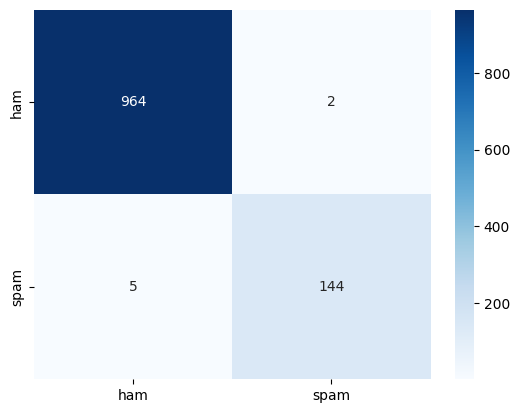

ROC-AUC: 0.9944002112079148


In [ ]:
# -----------------------------
# Confusion Matrix + Classification Report
# -----------------------------

print(classification_report(all_labels, preds, digits=4))

cm = confusion_matrix(all_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.show()

roc_auc = roc_auc_score(all_labels, all_logits[:,1])
print("ROC-AUC:", roc_auc)


## Evaluation finale

### Comparaison des modèles 
- Matrice de confusion, courbe ROC, PR curve (utile si classes très déséquilibrées).
- Examiner faux positifs & faux négatifs — souvent instructif pour règles heuristiques.
- Interprétabilité / règles complémentaires


Mise en production du modèle
- Export / déploiement
- Sauvegarder modèle (TF/Keras .h5, PyTorch .pt, ou un pipeline scikit-learn avec joblib).
